# Match labelled rows with LLM-extracted rows
1. Load data
2. Vectorize rows
3. Match rows 
4. Compute accuracy


In [1]:
import datetime as dt
import geopandas as gpd
from matplotlib import pyplot as plt
from src.data import *
from src.post_process_functions import *
from src.hazard_def import *
from src.impact_def import *
from src.accuracy import *

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/lseverino/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /Users/lseverino/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/lseverino/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Load data

In [2]:
#load data (model)
model = "meta-llama_llama-4-scout-17b-16e-instruct"
#"llama-3.1-8b-instant"#"llama-3.3-70b-versatile"
# #"meta-llama_llama-4-scout-17b-16e-instruct"
res_savename_ext = "post_processed_llm_response_impact_labelled_reports_test_multiprompt_continue_v050925_21rep_meta-llama_llama-4-scout-17b-16e-instruct"
#f"post_processed_flags_labelled_reports_{model}_v230925"
#"post_processed_llm_response_impact_labelled_reports_test_multiprompt_continue_v050925_21rep_meta-llama_llama-4-scout-17b-16e-instruct"
#"post_processed_labelled_reports_test_date_meta-llama_llama-4-scout-17b-16e-instruct_v180925"
extracted_df_no_geo = pd.read_csv(DATA_OUT_PROC / (res_savename_ext+".csv"))

#load data (labelled)
res_savename_lab = "post_processed_labelled_reports_impacts_all_v080925"
#"post_processed_flags_labelled_reports_impacts_all_v240925"
# "post_processed_labelled_reports_impacts_all_v080925"
labelled_df_no_geo = pd.read_csv(DATA_OUT_PROC / (res_savename_lab+".csv"))

split_lowest = False
suffix = "_geo_split_lowest" if split_lowest else "_geo"
suffix2 ="_v300925"
#load geocoded data
extracted_df = gpd.read_file(DATA_OUT_PROC / (res_savename_ext+suffix+".gpkg"))#(res_savename_ext+suffix+suffix2+".gpkg")
suffix2 ="_v300925"
#load data (labelled)
labelled_df = gpd.read_file(DATA_OUT_PROC / (res_savename_lab+suffix+".gpkg"))#(res_savename_lab+suffix+suffix2+".gpkg")

In [3]:
#reformat output
num_cols = ["impactValue","startYear", "startMonth", "startDay", "endYear", "endMonth", "endDay"]
list_cols_ext = ["country", "location", "hazards", "valueAnnotation", "locationAnnotation", "dateAnnotation", "hazardsAnnotation"]
list_cols_lab = ["country", "location", "hazards", "annotation"]
labelled_df = format_output(labelled_df, num_cols=num_cols, list_cols=list_cols_lab)
extracted_df = format_output(extracted_df, num_cols=num_cols, list_cols=list_cols_ext)

##for matching, need to replace NaNs in dates and units as np.nan cannot be compared
labelled_df[["startYear", "startMonth", "startDay", "endYear", "endMonth", "endDay"]] = labelled_df[["startYear", "startMonth", "startDay", "endYear", "endMonth", "endDay"]].fillna(-1)
extracted_df[["startYear", "startMonth", "startDay", "endYear", "endMonth", "endDay"]] = extracted_df[["startYear", "startMonth", "startDay", "endYear", "endMonth", "endDay"]].fillna(-1)
labelled_df["impactUnit"] = labelled_df["impactUnit"].fillna("null")
extracted_df["impactUnit"] =extracted_df["impactUnit"].fillna("null")

DEF_CRS_EPSG = "EPSG:4326"
labelled_df = labelled_df.set_crs(DEF_CRS_EPSG, allow_override=True)
extracted_df = extracted_df.set_crs(DEF_CRS_EPSG, allow_override=True)
combined_df = pd.concat([labelled_df, extracted_df])


## Match
1. Vectorize columns that need to be compared using cosine similarity
2. Compute cosine similarity for those columns for each possible extracted-labelled pair
3. Add absolute difference of impactValue between each possible extracted-labelled pair.
    Need to consider NaN from not NaN separately. Only try matching non-NaNs with non-NaNs 
    (and nans with nan?)
4. Compute Intersection-Over-Union of polygons for each possible pair
5. Match by maximizing similarity and -impactvalu_idff and -IoT. Allow for more than one match.  

TO DO:
- Decide if not nan can be matched with nan and vice versa or not

In [4]:
#labelled_df = labelled_df[labelled_df["appealCode"] == "MDRSV012"]
#extracted_df = extracted_df[extracted_df["appealCode"] == "MDRSV012"]

In [5]:
# weights for matching
weight_set = dict()
weight_set["ws1"] = {#only impsubtype and unit
    'hazards' : 0,
    'country' : 0,
    'startYear' : 0,
    'startMonth' : 0,
    'startDay' : 0,
    'endYear' : 0,
    'endMonth' : 0,
    'endDay' : 0,
    'impactSubtype' : 1,
    'impactUnit' : 1,
    'geometry' : 0, #weight for geometry matching
    'impactValue' : 0
    }
weight_set["ws2"] = {#biased towards impsubtype and impunit
    'hazards' : 1,
    'country' : 2,
    'startYear' : 2,
    'startMonth' : 1,
    'startDay' : 1,
    'endYear' : 1,
    'endMonth' : 1,
    'endDay' : 1,
    'impactSubtype' : 14, #bigger than sum of all other weights (12)
    'impactUnit' : 14,
    'geometry' : 2, #weight for geometry matching
    'impactValue' : 1
    }

weight_set["ws3"] = {#flat
    'hazards' : 1,
    'country' : 1,
    'startYear' : 1,
    'startMonth' : 1,
    'startDay' : 1,
    'endYear' : 1,
    'endMonth' : 1,
    'endDay' : 1,
    'impactSubtype' : 1, #bigger than sum of all other weights (12)
    'impactUnit' : 1,
    'geometry' : 1, #weight for geometry matching
    'impactValue' : 1
    }
weight_set["ws4"] = {#only impsubtype
    'hazards' : 0,
    'country' : 0,
    'startYear' : 0,
    'startMonth' : 0,
    'startDay' : 0,
    'endYear' : 0,
    'endMonth' : 0,
    'endDay' : 0,
    'impactSubtype' : 1,
    'impactUnit' : 0,
    'geometry' : 0, #weight for geometry matching
    'impactValue' : 0
    }

In [6]:
extracted_df.replace({"Access to Transport and Mobility" : "Mobility and Access to Transport",
                      "Access to transport and Mobility" : "Mobility and Access to Transport",
                      "Agriculture Infrastructure" : "Agricultural Infrastructure",
                      "Other Economic and Livelihood Impacts" : "Other Economic Activity & Livelihood Production",
                      "Informal settlements" : "Informal Settlements"}, inplace=True)
labelled_df.replace({"Access to Transport and Mobility" : "Mobility and Access to Transport",
                      "Access to transport and Mobility" : "Mobility and Access to Transport",
                      "Agriculture Infrastructure" : "Agricultural Infrastructure",
                      "Other Economic and Livelihood Impacts" : "Other Economic Activity & Livelihood Production",
                      "Informal settlements" : "Informal Settlements"}, inplace=True)
#labelled_df = extracted_df


In [20]:
## Parameters
geo_match = True
value_match_pre = False #minimize diff of impactValue simultaneously as cat columns
value_match_post = True #minimize diff of impactValue after matching of cat columns
impactValue_error_clip = None
loose_nan_policy = True #allow NaNs from one side to be matched with all rows from the other side

unique_countries_ISO = [country.alpha_3 for country in pycountry.countries]
unique_country_names = [country.name for country in pycountry.countries]
pattern = '|'.join(map(re.escape, unique_country_names))

unique_dict = {#mapping dictonary of unique values to generate vectors for cosine similarity
    'hazards' : list(hazard_main_types_emdat_desc.keys()),
    'country' : unique_country_names,
    'startYear' : np.arange(1980, 2026).tolist()+[-1],
    'startMonth' : np.arange(1, 13).tolist()+[-1],
    'startDay' : np.arange(1, 32).tolist()+[-1],
    'endYear' : np.arange(1980, 2026).tolist()+[-1],
    'endMonth' : np.arange(1, 13).tolist()+[-1],
    'endDay' : np.arange(1, 32).tolist()+[-1],
    'impactSubtype' : list(impact_subtypes_desc_dict.keys()),
    'impactUnit' : combined_df.impactUnit.unique().tolist(),
}
ws_key = "ws2"
matching_cols_weights = weight_set[ws_key] # weights for matching
### ! similarity cols and matching cols must be in the same order
similarity_cols = list(unique_dict.keys()) #all cols for which cosine similarity needs to be computed
matching_cols = list(matching_cols_weights.keys()) #cols used for matching
#accuracy_cols = list(unique_dict.keys()) + ["geometry"]

## Saving
save_results = True
sim_name = f"{ws_key}-geo-valuepost-loosenan"
filename_out = f"matched_data_{sim_name}_{res_savename_ext}"
match_idx = []

##Matching
#updating matching columns and weights according to parameters
if not geo_match:
    matching_cols.remove("geometry")
if not value_match_pre:
    matching_cols.remove("impactValue")
else:
    impactValue_error_clip = (0,1)


for appeal, ext_group in extracted_df.groupby("appealCode"):
    print("Processing appeal", appeal)
    ext_group = ext_group.reset_index(drop=False, names=["orig_index"]) #need to reset index to get indices for numpy arrays
    lab_group = labelled_df[labelled_df["appealCode"] == appeal].reset_index(drop=False, names=["orig_index"])

    if (lab_group.shape[0] == 0) or (ext_group.shape[0] == 0):
        continue

    #vectorize
    ext_vect_df = pd.DataFrame(columns=similarity_cols)
    lab_vect_df = pd.DataFrame(columns=similarity_cols)

    for col in similarity_cols:
        ext_vect_df[col] = ext_group[col].apply(vectorize, unique_values=unique_dict[col])
        lab_vect_df[col] = lab_group[col].apply(vectorize, unique_values=unique_dict[col])

    #initialize
    reid_match_ext_group= np.array([])
    reid_match_lab_group = np.array([])
    accuracy_matrix_group = []

    #split between not nans and nans for impactValue
    not_nan_ext_df, not_nan_lab_df, nan_ext_df, nan_lab_df = split_nans(ext_group, lab_group, "impactValue", loose_nan_policy=loose_nan_policy)
    if len(not_nan_ext_df) and len(not_nan_lab_df):
        ext_vect_df_notna = ext_vect_df.loc[not_nan_ext_df.index]
        lab_vect_df_notna = lab_vect_df.loc[not_nan_lab_df.index]

        reid_match_ext, reid_match_lab, accuracy_matrix = match_rows(not_nan_ext_df, not_nan_lab_df, ext_vect_df_notna, lab_vect_df_notna, matching_cols, similarity_cols,  matching_cols_weights, geo_match=geo_match, value_match_pre=value_match_pre, value_match_post=value_match_post)

        #store results for group
        accuracy_matrix_group.append(accuracy_matrix)
        reid_match_ext_group = np.append(reid_match_ext_group, reid_match_ext)
        reid_match_lab_group = np.append(reid_match_lab_group, reid_match_lab)

    if len(nan_ext_df) and len(nan_lab_df):
        ext_vect_df_na = ext_vect_df.loc[nan_ext_df.index]
        lab_vect_df_na = lab_vect_df.loc[nan_lab_df.index]

        #turn off value match for nans
        reid_match_ext, reid_match_lab, accuracy_matrix = match_rows(nan_ext_df, nan_lab_df, ext_vect_df_na, lab_vect_df_na, matching_cols, similarity_cols, matching_cols_weights,  geo_match=geo_match, value_match_pre=False, value_match_post=False)

        #need to append cols of nan to keep dim consistent if there are no impactValues
        if value_match_pre: #or value_match_post:
            accuracy_matrix = np.append(accuracy_matrix, np.full((accuracy_matrix.shape[0], 1), np.nan), axis=1)

        #store results for group
        accuracy_matrix_group.append(accuracy_matrix)
        reid_match_ext_group = np.append(reid_match_ext_group, reid_match_ext)
        reid_match_lab_group = np.append(reid_match_lab_group, reid_match_lab)

    #write as df
    id_accuracy_array = np.append(np.stack((reid_match_ext_group, reid_match_lab_group),axis=1), np.concatenate(accuracy_matrix_group), axis=1)
    match_idx.append(pd.DataFrame(id_accuracy_array,
                                  columns = ["ext_match_id", "lab_match_id"]+matching_cols+["match"]))

match_idx_df = pd.concat(match_idx)

#join extracted and labelled dataframes
matched_df = pd.concat([extracted_df.loc[match_idx_df["ext_match_id"].values].reset_index(drop=True),
                        labelled_df.loc[match_idx_df["lab_match_id"].values].add_suffix('_matched').reset_index(drop=True),
                        match_idx_df.reset_index(drop=True).add_suffix('_sim')], axis=1)
#overwrite / recompute impactValue sim and error
matched_df["impactValue_error"] = max_value_diff(matched_df["impactValue"].values, matched_df["impactValue_matched"].values)
#matched_df["impactValue_sim"] = calc_value_sim(matched_df["impactValue"].values, matched_df["impactValue_matched"].values)#[np.arange(len(matched_df)), np.arange(len(matched_df))]
if "geometry_sim" not in matched_df.columns:
    matched_df["geometry_sim"] = matched_df.apply(lambda x: IoU(x["geometry"], x["geometry_matched"]), axis=1)

if save_results:
    matched_df = delistify_cols(matched_df)
    matched_df.to_feather(DATA_OUT_PROC / (filename_out + ".feather"))


Processing appeal MDRBD022
Processing appeal MDRBJ019
Processing appeal MDRCM039
Processing appeal MDRCN006
Processing appeal MDRDZ011
Processing appeal MDRGE019
Processing appeal MDRIQ014
Processing appeal MDRKE058
Processing appeal MDRMY003
Processing appeal MDRMZ024
Processing appeal MDRNG041
Processing appeal MDRPH021
Processing appeal MDRPK026
Processing appeal MDRRW022
Processing appeal MDRS2001
Processing appeal MDRSD034
Processing appeal MDRSV012
Processing appeal MDRTN010
Processing appeal MDRUG050
Processing appeal MDRYE011
Processing appeal MDRZM022


In [8]:
matched_df = gpd.read_feather(DATA_OUT_PROC / (filename_out + ".feather"))

In [21]:
matched_df[["appealCode", "match_sim", "impactSubtype", "impactSubtype_matched", "impactSubtype_sim", "impactValue", "impactValue_matched", "impactValue_error", "impactUnit","impactUnit_matched", "impactUnit_sim", "location", "location_matched", "geometry_sim", "valueAnnotation", "annotation_matched"]]

,appealCode,match_sim,impactSubtype,impactSubtype_matched,impactSubtype_sim,impactValue,impactValue_matched,impactValue_error,impactUnit,impactUnit_matched,impactUnit_sim,location,location_matched,geometry_sim,valueAnnotation,annotation_matched
0,MDRBD022,0.992678,Affected People,Affected People,1.0,2176519.00,2176519.00,0.0,people,people,1.0,"['[\'Kurigram\', \'Gaibandha\', \'Lalmonirhat\...","['Kurigram district', 'Gaibandha district', 'L...",1.0,['According to National disaster response coor...,"['of affected population 2,176,519 No.', 'Six ..."
1,MDRBD022,1.000000,Displaced People,Displaced People,1.0,31818.00,31818.00,0.0,people,people,1.0,[],"['Kurigram district', 'Gaibandha district', 'L...",1.0,"['Situation at a glance, as of16 July2019 No. ...","['of people who have moved to safe shelter 31,..."
2,MDRBD022,1.000000,Residential Buildings,Residential Buildings,1.0,3988.00,3988.00,0.0,homes,homes,1.0,[],"['Kurigram district', 'Gaibandha district', 'L...",1.0,"['Situation at a glance, as of16 July2019 No. ...","['of fully damaged house 3,988 No.', 'Six days..."
3,MDRBD022,1.000000,Residential Buildings,Residential Buildings,1.0,98571.00,98571.00,0.0,homes,homes,1.0,[],"['Kurigram district', 'Gaibandha district', 'L...",1.0,"['Situation at a glance, as of16 July2019 No. ...","['of partially damaged house 98,571 No.', 'Six..."
4,MDRBD022,0.642678,Crop Production and Forestry,Crop Production and Forestry,1.0,147.33,147.33,0.0,km**2,km**2 of crop production and forestry,0.0,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Kurigram district', 'Gaibandha district', 'L...",1.0,['According to National disaster response coor...,"['of people who have moved to safe shelter 31,..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
486,MDRZM022,0.500000,Access to Education,Affected Livestock and Animals,0.0,NaN,NaN,NaN,null,null,1.0,"['Southern Province', 'Central Province', 'Eas...","['North-Western province', 'Southern province'...",1.0,['The situation has come at a time when the go...,['Page 1 / 21 DREF Operation Zambia Drought 20...
487,MDRZM022,0.500000,Access to Education,Other Economic Activity & Livelihood Production,0.0,NaN,NaN,NaN,null,null,1.0,"['Southern Province', 'Central Province', 'Eas...","['North-Western province', 'Southern province'...",1.0,['The situation has come at a time when the go...,['Page 1 / 21 DREF Operation Zambia Drought 20...
488,MDRZM022,0.600000,Access to Power and Energy,Water Quality and Availability,0.0,NaN,NaN,NaN,null,null,1.0,"['Southern Province', 'Western Province', 'Nor...","['North-Western province', 'Southern province'...",1.0,['Pasture is drying up making is difficult for...,['Page 1 / 21 DREF Operation Zambia Drought 20...
489,MDRZM022,0.600000,Mobility and Access to Transport,Affected Livestock and Animals,0.0,NaN,NaN,NaN,null,null,1.0,"['Southern Province', 'North-Western', 'Southe...","['North-Western province', 'Southern province'...",1.0,['The whole Southern half of Zambia is experie...,['Page 1 / 21 DREF Operation Zambia Drought 20...


In [10]:
matched_df[matched_df["appealCode"] == "MDRSV012"][["appealCode", "impactSubtype", "impactSubtype_matched" ,"impactValue", "impactUnit", "impactValue_matched", "impactUnit_matched", "location", "location_matched", "valueAnnotation", "annotation_matched"]]

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactUnit,impactValue_matched,impactUnit_matched,location,location_matched,valueAnnotation,annotation_matched
360,MDRSV012,Affected People,Injured People,7085.0,people,14.0,people,"['eastern regions', 'San Miguel', 'La Unión de...","['Morazn department', 'La Union department', '...","['Number of people affected:7,085 (1,417 famil...",['Situation analysis Description of the disast...
361,MDRSV012,Injured People,Injured People,14.0,people,14.0,people,[],"['Morazn department', 'La Union department', '...",['Injured14'],['Situation analysis Description of the disast...
362,MDRSV012,Human Deaths,Human Deaths,4.0,people,1.0,people,[],"['Morazn department', 'La Union department', '...",['Dead4'],['Situation analysis Description of the disast...
363,MDRSV012,Homeless People,Injured People,1090.0,people,14.0,people,"['San Miguel', 'La Unión', 'Usulután', 'Sonson...","['Morazn department', 'La Union department', '...","['Sheltered1,090']",['Situation analysis Description of the disast...
364,MDRSV012,Residential Buildings,Residential Buildings,1409.0,homes,1409.0,homes,"['the cantons of El Brazo, La Canoa and El Tec...","['Morazn department', 'La Union department', '...","['Flooded homes1,409']",['Situation analysis Description of the disast...
365,MDRSV012,Residential Buildings,Residential Buildings,2.0,homes,2.0,homes,"['the cantons of El Brazo, La Canoa and El Tec...","['Morazn department', 'La Union department', '...",['Destroyed homes2'],['Situation analysis Description of the disast...
366,MDRSV012,Road Infrastructure,Road Infrastructure,31.0,roads,31.0,roads,[],"['Morazn department', 'La Union department', '...",['Affected rods31'],['Situation analysis Description of the disast...
367,MDRSV012,Road Infrastructure,Road Infrastructure,24.0,roads,24.0,roads,[],"['Morazn department', 'La Union department', '...",['Affected highways24'],['Situation analysis Description of the disast...
368,MDRSV012,Road Infrastructure,Road Infrastructure,3.0,roads,24.0,roads,[],"['Morazn department', 'La Union department', '...",['Flooded roads3'],['Situation analysis Description of the disast...
369,MDRSV012,Road Infrastructure,Road Infrastructure,1.0,roads,24.0,roads,[],"['Morazn department', 'La Union department', '...",['Flooded highways1'],['Situation analysis Description of the disast...


<Axes: ylabel='appealCode'>

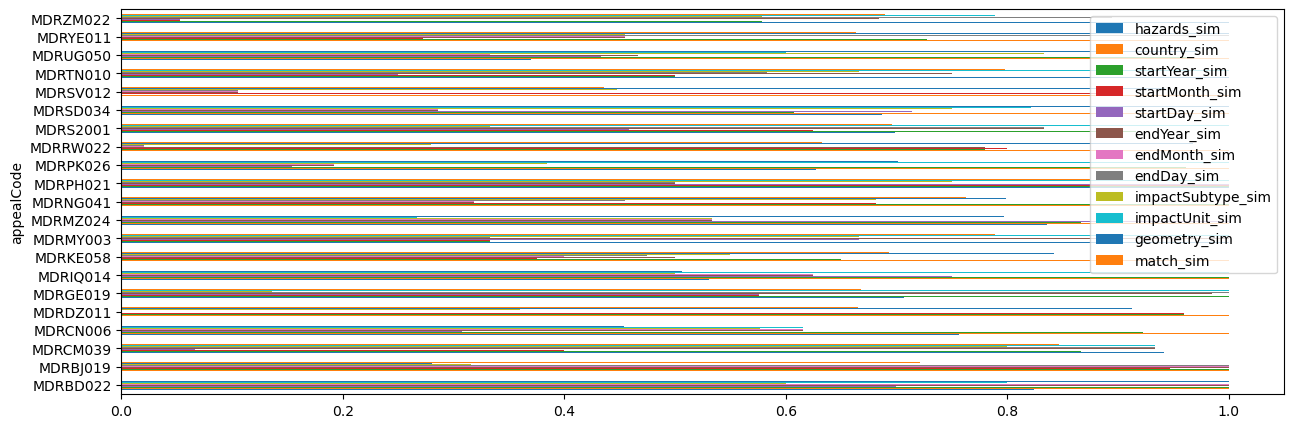

In [22]:
sim_cols = [match_col for match_col in matched_df.columns if "sim" in match_col and match_col not in ["lab_match_id_sim", "ext_match_id_sim"]]
matched_df.groupby("appealCode")[sim_cols].mean().plot(kind="barh", figsize=(15, 5))

<Axes: >

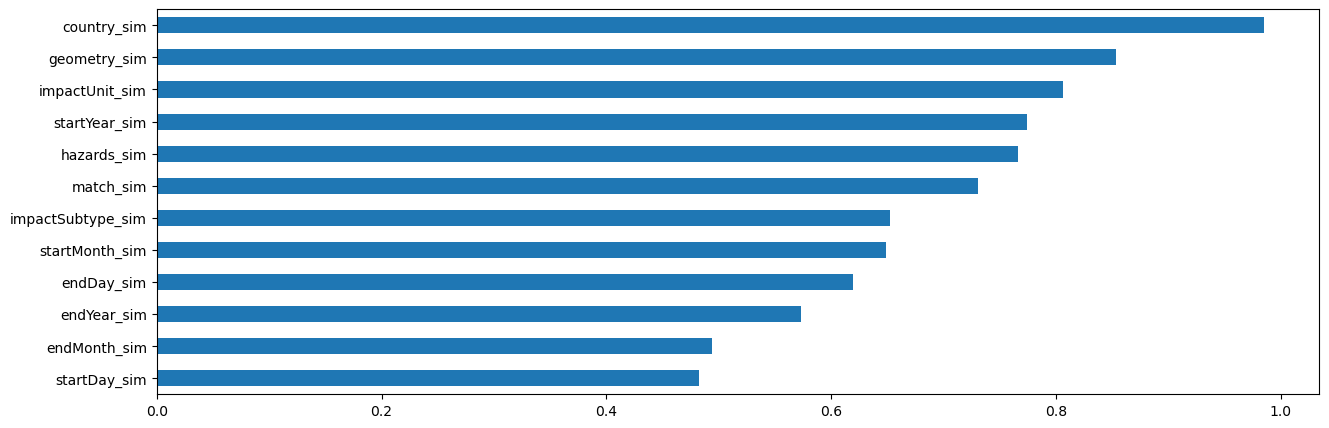

In [26]:
matched_df.groupby("ext_match_id_sim")[sim_cols].mean().mean().sort_values().plot(kind="barh", figsize=(15, 5))

In [25]:
matched_df[["appealCode","impactSubtype", "impactSubtype_matched", "impactValue", "impactUnit", "impactValue_matched", "impactUnit_matched", "location", "location_matched"]]

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactUnit,impactValue_matched,impactUnit_matched,location,location_matched
0,MDRBD022,Affected People,Affected People,2176519.00,people,2176519.00,people,"['[\'Kurigram\', \'Gaibandha\', \'Lalmonirhat\...","['Kurigram district', 'Gaibandha district', 'L..."
1,MDRBD022,Displaced People,Displaced People,31818.00,people,31818.00,people,[],"['Kurigram district', 'Gaibandha district', 'L..."
2,MDRBD022,Residential Buildings,Residential Buildings,3988.00,homes,3988.00,homes,[],"['Kurigram district', 'Gaibandha district', 'L..."
3,MDRBD022,Residential Buildings,Residential Buildings,98571.00,homes,98571.00,homes,[],"['Kurigram district', 'Gaibandha district', 'L..."
4,MDRBD022,Crop Production and Forestry,Crop Production and Forestry,147.33,km**2,147.33,km**2 of crop production and forestry,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Kurigram district', 'Gaibandha district', 'L..."
...,...,...,...,...,...,...,...,...,...
486,MDRZM022,Access to Education,Affected Livestock and Animals,NaN,null,NaN,null,"['Southern Province', 'Central Province', 'Eas...","['North-Western province', 'Southern province'..."
487,MDRZM022,Access to Education,Other Economic Activity & Livelihood Production,NaN,null,NaN,null,"['Southern Province', 'Central Province', 'Eas...","['North-Western province', 'Southern province'..."
488,MDRZM022,Access to Power and Energy,Water Quality and Availability,NaN,null,NaN,null,"['Southern Province', 'Western Province', 'Nor...","['North-Western province', 'Southern province'..."
489,MDRZM022,Mobility and Access to Transport,Affected Livestock and Animals,NaN,null,NaN,null,"['Southern Province', 'North-Western', 'Southe...","['North-Western province', 'Southern province'..."


In [14]:
matched_df[matched_df["hazards"]!= matched_df["hazards_matched"]][["appealCode","impactSubtype", "impactSubtype_matched", "impactValue", "impactUnit", "impactValue_matched", "impactUnit_matched", "location", "location_matched"]]

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactUnit,impactValue_matched,impactUnit_matched,location,location_matched
0,MDRBD022,Affected People,Affected People,2176519.00,people,2176519.00,people,"['[\'Kurigram\', \'Gaibandha\', \'Lalmonirhat\...","['Kurigram district', 'Gaibandha district', 'L..."
4,MDRBD022,Crop Production and Forestry,Crop Production and Forestry,147.33,km**2,147.33,km**2 of crop production and forestry,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Kurigram district', 'Gaibandha district', 'L..."
5,MDRBD022,Affected People,Affected People,50000.00,people,2176519.00,people,"['[\'Kurigram\', \'Gaibandha\', \'Lalmonirhat\...",[]
7,MDRBD022,"Water, Sanitation, and Hygiene Infrastructure",Other Infrastructure Impacts,NaN,null,NaN,null,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Kurigram district', 'Gaibandha district', 'L..."
8,MDRBD022,"Water, Sanitation, and Hygiene Infrastructure",Other Infrastructure Impacts,NaN,null,NaN,null,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Gaddimari area', 'Lalmonirhats Hatibandha']"
...,...,...,...,...,...,...,...,...,...
427,MDRYE011,"Water, Sanitation, and Hygiene Infrastructure","Water, Sanitation, and Hygiene Infrastructure",NaN,null,NaN,null,"['[\'Al-Mahra\', \'Al-Mahwit\', \'Taiz\', \'Ib...","['Al-Mahra', 'Al-Mahwit', 'Hadramout', 'Dhamar..."
428,MDRYE011,Human Health and Wellbeing,Residential Buildings,NaN,null,NaN,null,"['[\'Al-Mahra\', \'Al-Mahwit\', \'Taiz\', \'Ib...","['Al-Mahra', 'Al-Mahwit', 'Hadramout', 'Dhamar..."
429,MDRYE011,Human Health and Wellbeing,Other Economic Activity & Livelihood Production,NaN,null,NaN,null,"['[\'Al-Mahra\', \'Al-Mahwit\', \'Taiz\', \'Ib...","['Al-Mahra', 'Al-Mahwit', 'Hadramout', 'Dhamar..."
430,MDRYE011,Human Health and Wellbeing,"Water, Sanitation, and Hygiene Infrastructure",NaN,null,NaN,null,"['[\'Al-Mahra\', \'Al-Mahwit\', \'Taiz\', \'Ib...","['Al-Mahra', 'Al-Mahwit', 'Hadramout', 'Dhamar..."


In [15]:
matched_df[matched_df["appealCode"] == "MDRGE019"][["appealCode","match_sim","impactSubtype", "impactSubtype_matched", "impactValue", "impactUnit", "impactValue_matched", "impactUnit_matched", "location", "location_matched"]]

,appealCode,match_sim,impactSubtype,impactSubtype_matched,impactValue,impactUnit,impactValue_matched,impactUnit_matched,location,location_matched
82,MDRGE019,0.542678,Affected People,Access to Power and Energy,28870.0,people,30000.0,people,"['Adjara Aut.', 'Rep.', 'Guria', 'Imereti', 'M...",['Imereti']
83,MDRGE019,0.942678,Human Deaths,Human Deaths,3.0,people,1.0,people,[],[]
84,MDRGE019,0.942678,Access to Power and Energy,Access to Power and Energy,30000.0,people,30000.0,people,['Imereti'],['Imereti']
85,MDRGE019,0.592678,Access to Education,Road Infrastructure,NaN,null,NaN,null,"['Guria', 'Adjara', 'Imereti', 'Mtskheta-Mtian...","['Guria', 'Chokhatauri', 'Gogole District', 'O..."
86,MDRGE019,0.592678,Access to Education,Residential Buildings,NaN,null,NaN,null,"['Guria', 'Adjara', 'Imereti', 'Mtskheta-Mtian...",[]
...,...,...,...,...,...,...,...,...,...,...
143,MDRGE019,0.642678,Agricultural Infrastructure,Access to Power and Energy,NaN,null,NaN,null,"['Guria', 'Adjara', 'Imereti', 'Mtskheta-Mtian...",['Adjara']
144,MDRGE019,0.642678,Agricultural Infrastructure,Access to Healthcare,NaN,null,NaN,null,"['Guria', 'Adjara', 'Imereti', 'Mtskheta-Mtian...","['Buknari', 'Kvenobani', 'Basileti']"
145,MDRGE019,0.642678,Agricultural Infrastructure,Access to Food,NaN,null,NaN,null,"['Guria', 'Adjara', 'Imereti', 'Mtskheta-Mtian...","['Buknari', 'Kvenobani', 'Basileti']"
146,MDRGE019,0.642678,Agricultural Infrastructure,Other Service Access Impacts,NaN,null,NaN,null,"['Guria', 'Adjara', 'Imereti', 'Mtskheta-Mtian...","['Jumati', 'Konchati', 'Kokati']"


In [16]:
matched_df[matched_df["appealCode"] == "MDRGE019"][sim_cols]

,hazards_sim,country_sim,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,impactSubtype_sim,impactUnit_sim,geometry_sim,match_sim
82,0.707107,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.542678
83,0.707107,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.942678
84,0.707107,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.942678
85,0.707107,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.592678
86,0.707107,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.592678
...,...,...,...,...,...,...,...,...,...,...,...,...
143,0.707107,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.642678
144,0.707107,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.642678
145,0.707107,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.642678
146,0.707107,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.642678
